## Simple Linear Regression (SLR) Intuition

### The Equation

The mathematical representation of a simple linear regression model is:

$$\hat{y} = mx + b$$


*(or in statistical notation: $\hat{y} = \beta_0 + \beta_1 x$)*

Where:

* **$\hat{y}$**: Predicted value
* **$x$**: Independent variable (feature)
* **$m$ (or $\beta_1$)**: **Slope / Weight / Coefficient** (How much $y$ changes for a 1-unit change in $x$)
* **$b$ (or $\beta_0$)**: **Y-intercept / Bias** (The value of $y$ when $x = 0$)

---

## Intuition

The core intuition behind Linear Regression is finding the **"Line of Best Fit."** This line is positioned such that the overall distance (error) between the actual data points and the points predicted by the line is minimized.

---

### How to find $m$ and $b$?

For a Simple Linear Regression model, the equation of the line is:

$$y = mx + b$$

The goal of the algorithm is to find the optimal values for $m$ and $b$ such that the **Error (Residuals)** between the actual values ($y$) and predicted values ($\hat{y}$) is minimized.

There are two primary ways to find these optimal parameters:

1. **Ordinary Least Squares (OLS):** A closed-form mathematical solution that calculates the exact parameters by minimizing the sum of the squared differences between the observed and predicted values.
2. **Gradient Descent:** An iterative optimization algorithm that starts with random values for $m$ and $b$ and gradually adjusts them to reduce the error until the lowest possible error (global minimum) is reached.

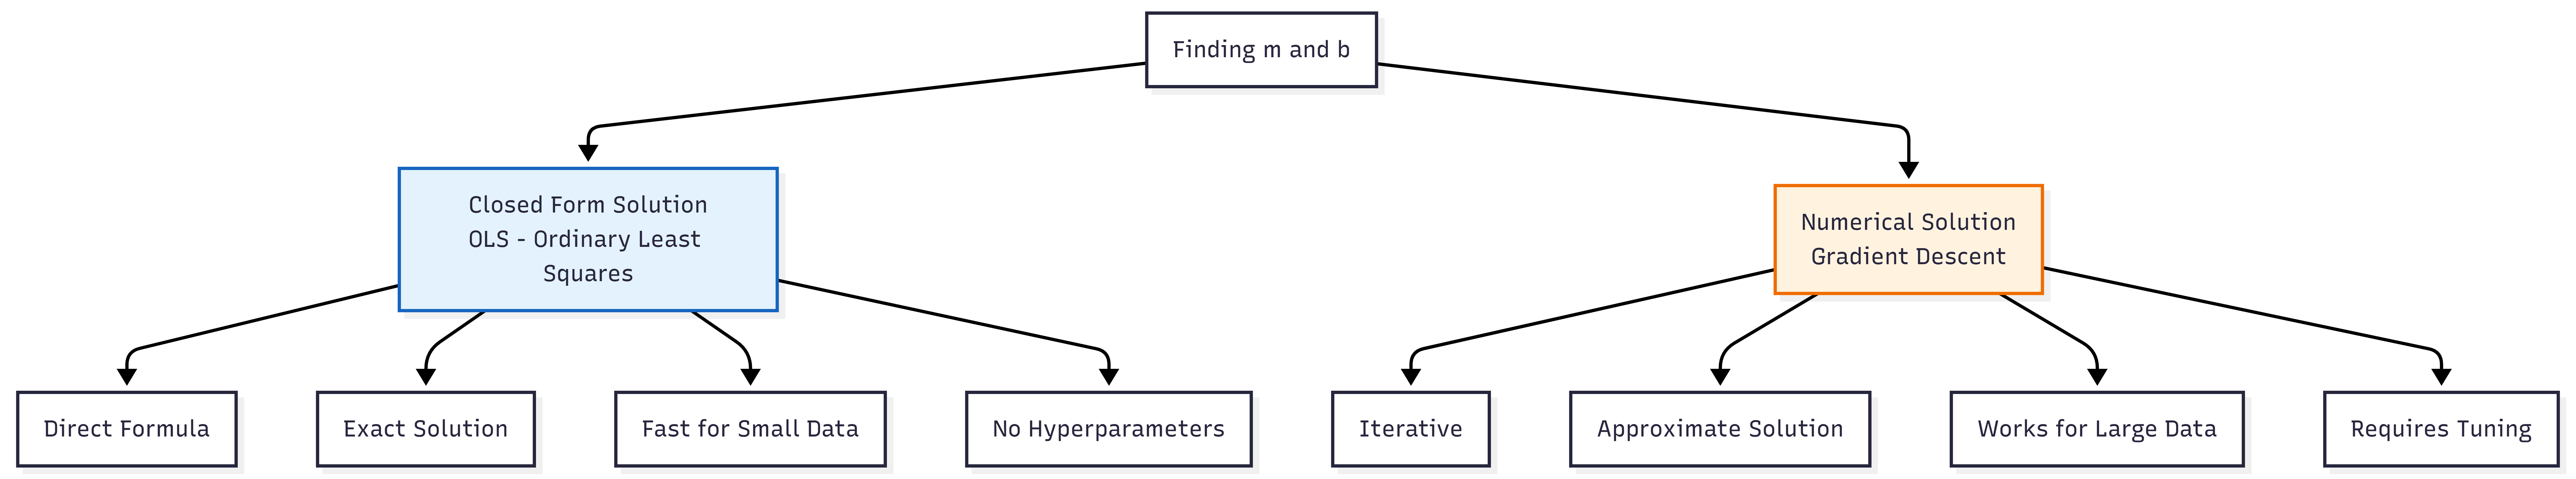

---

## Finding Parameters: OLS vs Gradient Descent

To find the best $m$ and $b$, we define an **Error Function (Cost Function)**. The most common is the **Mean Squared Error (MSE)**.

$$ J(m, b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

There are two primary ways to minimize this error function:

### 1. Closed-Form Solution: Ordinary Least Squares (OLS)
OLS uses linear algebra to find the exact mathematical solution in one step.

* **OLS Formula for slope ($m$):**

$$m = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}$$


* **OLS Formula for intercept ($b$):**

$$b = \bar{y} - m\bar{x}$$


**The OLS Formula (Matrix Form):**
$$ \hat{\beta} = (X^T X)^{-1} X^T y $$

*   **Pros:** Gives the exact global minimum, no need to tune hyperparameters, very fast for small to medium datasets.
*   **Cons:** Computationally expensive for large datasets (Matrix inversion $O(n^3)$ complexity), requires the matrix $(X^T X)$ to be invertible (fails if features are perfectly correlated / multicollinearity).



In [3]:
import numpy as np
import pandas as pd

# Create Synthetic Dataset
np.random.seed(42)
X = np.random.rand(100, 1) * 10  # 100 samples, 1 feature (0 to 10)
y = 3 * X.squeeze() + 5 + np.random.randn(100) * 2  # y = 3x + 5 + noise

# Convert to DataFrame
df = pd.DataFrame({
    'Feature': X.squeeze(),
    'Target': y
})

print("📊 Dataset Info:")
print(df.head(10))
print(f"\nDataset Shape: {df.shape}")
print(f"\nSummary Statistics:\n{df.describe()}")

📊 Dataset Info:
    Feature     Target
0  3.745401  16.410298
1  9.507143  32.923414
2  7.319939  27.143340
3  5.986585  18.984617
4  1.560186   9.241215
5  1.559945  10.394061
6  0.580836   9.698296
7  8.661761  29.948744
8  6.011150  21.416463
9  7.080726  25.238663

Dataset Shape: (100, 2)

Summary Statistics:
          Feature      Target
count  100.000000  100.000000
mean     4.701807   19.103262
std      2.974894    8.837473
min      0.055221    4.517970
25%      1.932008   11.572464
50%      4.641425   18.021013
75%      7.302031   27.029385
max      9.868869   36.170254


In [4]:
def ols_simple(X, y):
    """
    Ordinary Least Squares for Simple Linear Regression
    Returns: slope (m) and intercept (b)
    """
    n = len(X)

    # Calculate means
    x_mean = np.mean(X)
    y_mean = np.mean(y)

    # Calculate slope
    numerator = np.sum((X - x_mean) * (y - y_mean))
    denominator = np.sum((X - x_mean) ** 2)
    m = numerator / denominator

    # Calculate intercept
    b = y_mean - m * x_mean

    return m, b

# Example usage
X_flat = X.squeeze()  # Convert to 1D array
m, b = ols_simple(X_flat, y)
print(f"OLS Solution: y = {m:.4f}x + {b:.4f}")

OLS Solution: y = 2.9080x + 5.4302


In [5]:
def ols_multiple(X, y):
    """
    Ordinary Least Squares for Multiple Linear Regression
    Returns: coefficient vector β (including intercept)
    """
    # Add bias term (column of ones)
    X_bias = np.c_[np.ones((X.shape[0], 1)), X]

    # OLS formula: β = (XᵀX)⁻¹Xᵀy
    beta = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y

    return beta

# Example usage
beta = ols_multiple(X, y)
print(f"Beta coefficients: {beta}")
print(f"Intercept: {beta[0]:.4f}")
print(f"Slope: {beta[1]:.4f}")

Beta coefficients: [5.43019232 2.90804535]
Intercept: 5.4302
Slope: 2.9080


### 2. Non-Closed Form: Gradient Descent (GD)
GD is an iterative optimization algorithm. It starts with random values for $m$ and $b$, calculates the gradient (slope) of the error function, and takes steps in the opposite direction to reach the minimum.

**Update Rule:**
$$ \theta_{new} = \theta_{old} - \alpha \cdot \nabla J(\theta) $$
*(Where $\alpha$ is the Learning Rate)*

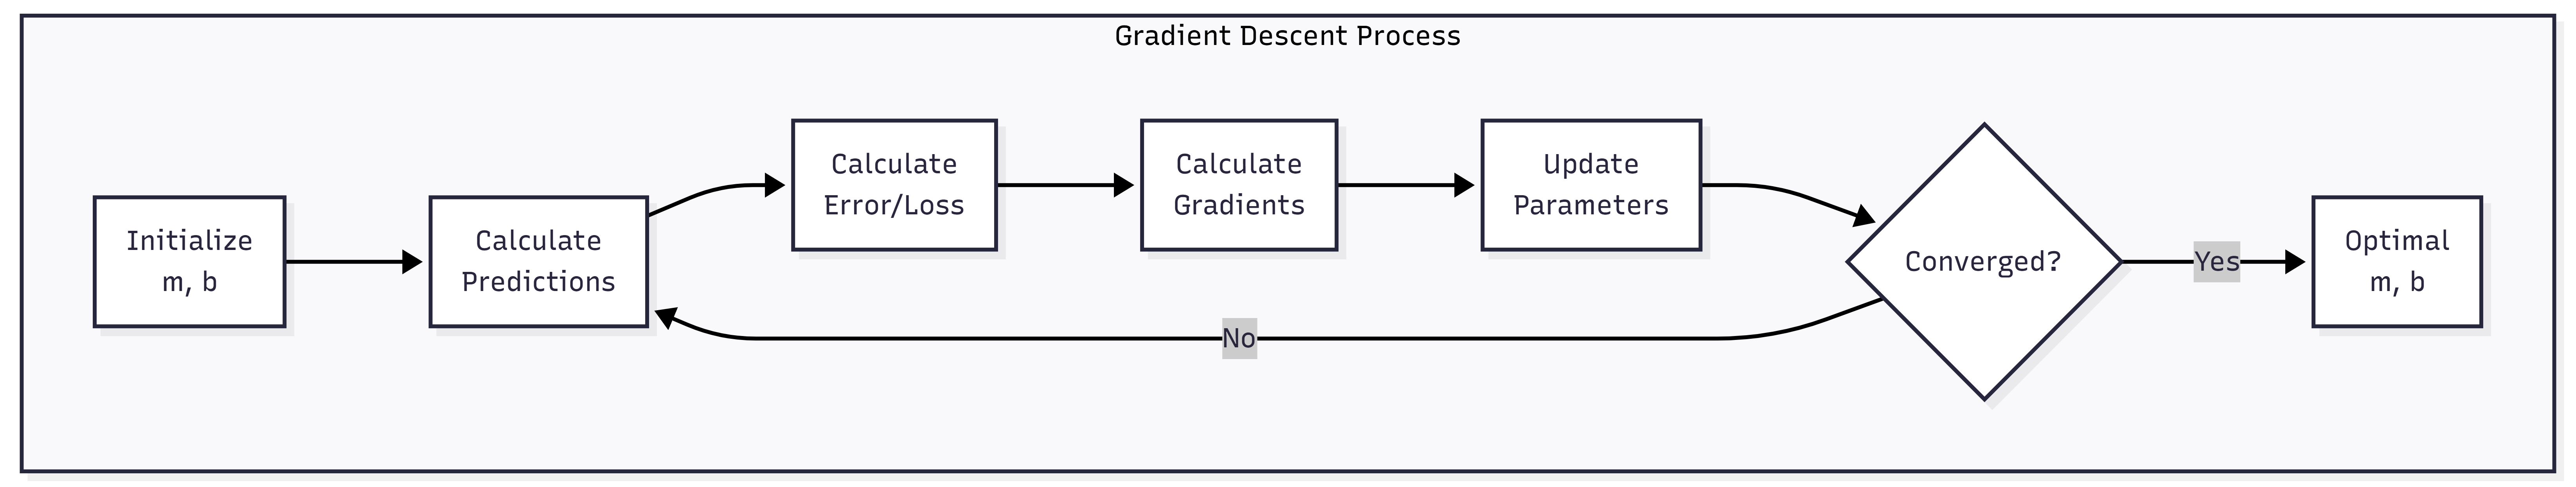

#### Types of Gradient Descent
| Aspect | Batch GD | Stochastic GD (SGD) | Mini-Batch GD |
|--------|----------|---------------------|---------------|
| **Data per Update** | All $n$ samples | 1 sample | Batch size (e.g., 32) |
| **Speed** | Slow | Very Fast | Moderate |
| **Convergence** | Smooth & Direct | Noisy & Oscillating | Moderate |
| **Memory** | High | Low | Moderate |




### Error Function (Cost Function)

To optimise the line, we need to measure how far off our predictions ($\hat{y}$) are from the actual values ($y$). The most common cost function used for optimisation is Mean Squared Error (MSE):


$$J(m, b) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - (mx_i + b))^2$$

#### The Impact of Learning Rate ($\alpha$)

```mermaid
graph LR
    subgraph "Learning Rate Impact"
        A[Learning Rate] --> B[Too High]
        A --> C[Optimal]
        A --> D[Too Low]
        
        B --> B1[Divergence]
        B --> B2[Unstable]
        B --> B3[Oscillating]
        
        C --> C1[Fast Convergence]
        C --> C2[Good Performance]
        C --> C3[Stable]
        
        D --> D1[Slow Convergence]
        D --> D2[May Get Stuck]
        D --> D3[Many Iterations]
    end
```



### OLS vs Gradient Descent: Decision Flow

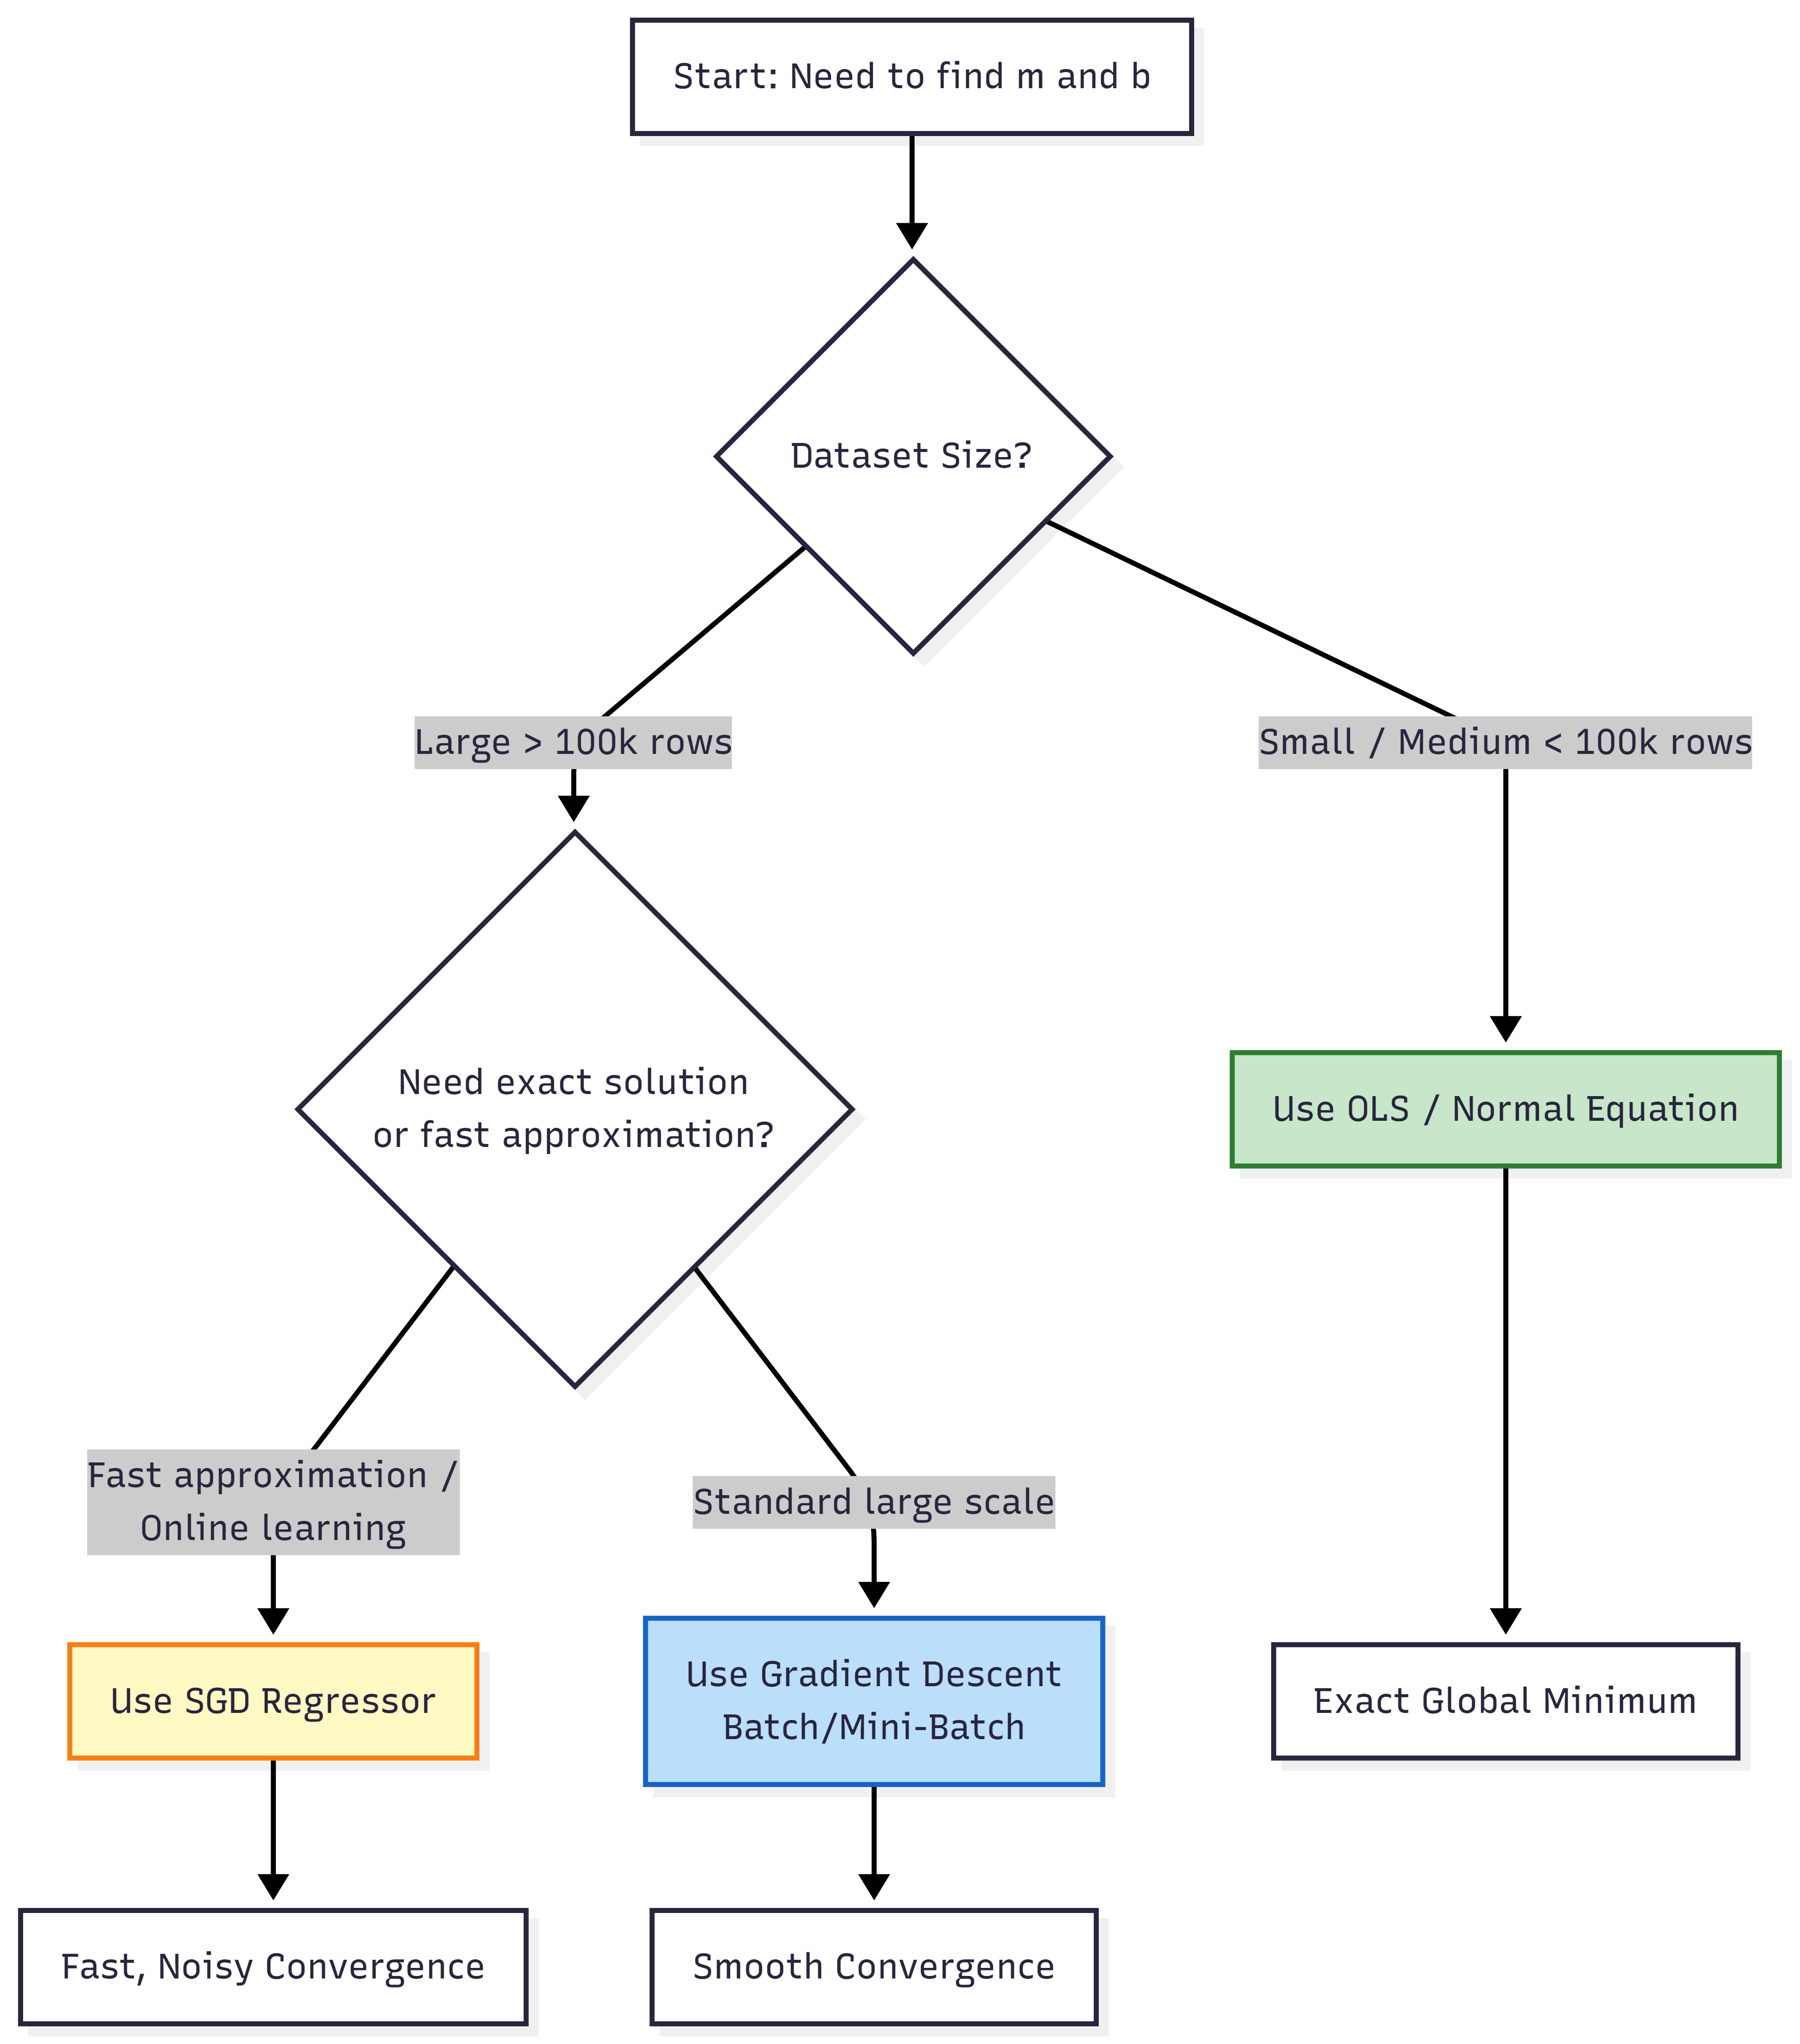


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================
# Create Synthetic Dataset
# ============================================
np.random.seed(42)
X = np.random.rand(100, 1) * 10  # 100 samples, 1 feature (0 to 10)
y = 3 * X.squeeze() + 5 + np.random.randn(100) * 2  # y = 3x + 5 + noise

# Convert to DataFrame
df = pd.DataFrame({
    'Feature': X.squeeze(),
    'Target': y
})

print("📊 Dataset Info:")
print(df.head(10))
print(f"\nDataset Shape: {df.shape}")
print(f"\nSummary Statistics:\n{df.describe()}")

📊 Dataset Info:
    Feature     Target
0  3.745401  16.410298
1  9.507143  32.923414
2  7.319939  27.143340
3  5.986585  18.984617
4  1.560186   9.241215
5  1.559945  10.394061
6  0.580836   9.698296
7  8.661761  29.948744
8  6.011150  21.416463
9  7.080726  25.238663

Dataset Shape: (100, 2)

Summary Statistics:
          Feature      Target
count  100.000000  100.000000
mean     4.701807   19.103262
std      2.974894    8.837473
min      0.055221    4.517970
25%      1.932008   11.572464
50%      4.641425   18.021013
75%      7.302031   27.029385
max      9.868869   36.170254


In [14]:
# ============================================
# Train-Test Split
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n🔹 Training Set Size: {len(X_train)} samples")
print(f"🔹 Test Set Size: {len(X_test)} samples")
print(f"🔹 Training/Test Ratio: {len(X_train)/len(X):.1%} / {len(X_test)/len(X):.1%}")


🔹 Training Set Size: 80 samples
🔹 Test Set Size: 20 samples
🔹 Training/Test Ratio: 80.0% / 20.0%


In [15]:
class GradientDescentLinearRegression:
    """
    Linear Regression using Gradient Descent optimization
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000, tol=1e-6):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.tol = tol  # Convergence tolerance
        self.weights = None
        self.bias = None
        self.history = {}

    def fit(self, X, y):
        """Train the model using Gradient Descent"""
        n_samples, n_features = X.shape

        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Track history for visualization
        self.history = {
            'cost': [],
            'weights': [],
            'bias': []
        }

        for i in range(self.n_iterations):
            # Forward pass: Make predictions
            y_pred = np.dot(X, self.weights) + self.bias

            # Compute cost
            cost = (1/n_samples) * np.sum((y - y_pred) ** 2)
            self.history['cost'].append(cost)
            self.history['weights'].append(self.weights.copy())
            self.history['bias'].append(self.bias)

            # Compute gradients
            dw = -(2/n_samples) * np.dot(X.T, (y - y_pred))
            db = -(2/n_samples) * np.sum(y - y_pred)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Check convergence
            if i > 0 and abs(self.history['cost'][-1] - self.history['cost'][-2]) < self.tol:
                print(f"✅ Converged at iteration {i+1}")
                break

            # Print progress
            if (i+1) % 100 == 0:
                print(f"Iteration {i+1}: Cost = {cost:.6f}")

        return self

    def predict(self, X):
        """Make predictions"""
        return np.dot(X, self.weights) + self.bias

    def get_parameters(self):
        """Return model parameters"""
        return self.weights, self.bias

# Example usage
gd_model = GradientDescentLinearRegression(
    learning_rate=0.01,
    n_iterations=1000
)
gd_model.fit(X_train, y_train)

# Get parameters
weights, bias = gd_model.get_parameters()
print(f"\n📈 Gradient Descent Results:")
print(f"  Slope: {weights[0]:.4f}")
print(f"  Intercept: {bias:.4f}")

Iteration 100: Cost = 5.496122
Iteration 200: Cost = 4.096364
Iteration 300: Cost = 3.627220
Iteration 400: Cost = 3.469982
Iteration 500: Cost = 3.417283
Iteration 600: Cost = 3.399620
Iteration 700: Cost = 3.393700
Iteration 800: Cost = 3.391716
Iteration 900: Cost = 3.391051
Iteration 1000: Cost = 3.390828

📈 Gradient Descent Results:
  Slope: 2.9228
  Intercept: 5.2659


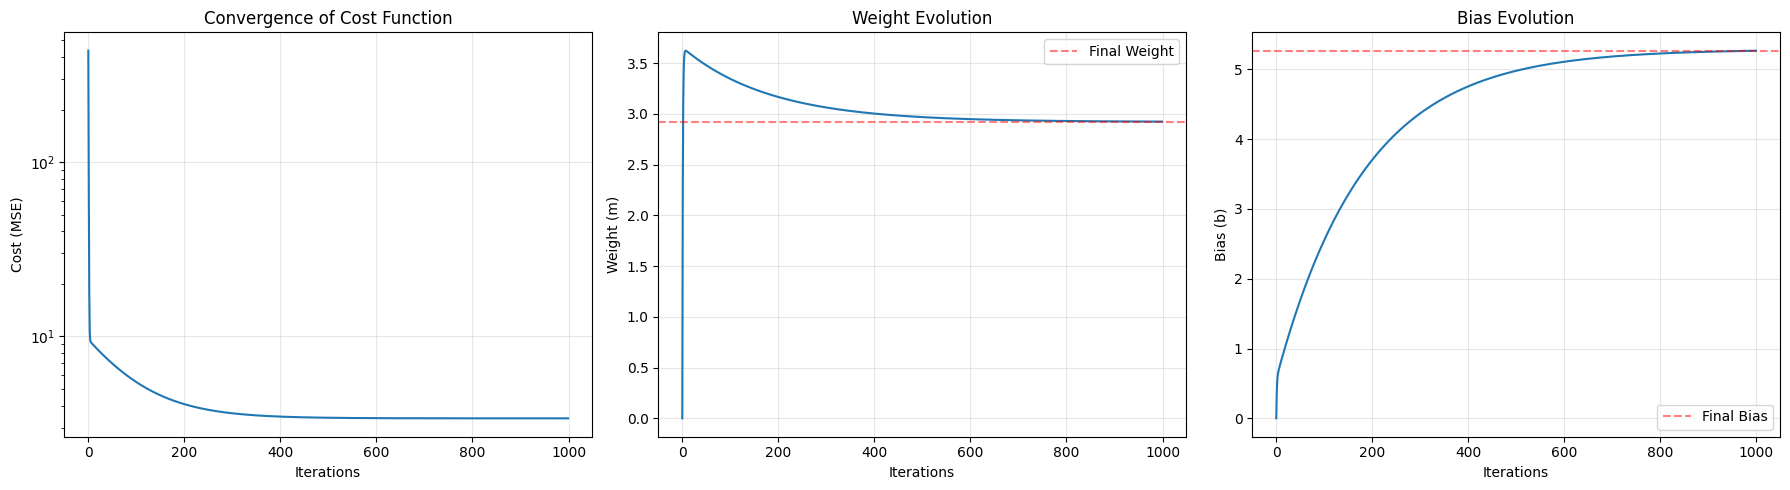

In [16]:
def plot_gradient_descent_history(model):
    """Visualize Gradient Descent convergence"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: Cost vs Iterations
    axes[0].plot(model.history['cost'])
    axes[0].set_xlabel('Iterations')
    axes[0].set_ylabel('Cost (MSE)')
    axes[0].set_title('Convergence of Cost Function')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_yscale('log')

    # Plot 2: Weight evolution
    weights_history = np.array(model.history['weights'])
    if weights_history.ndim > 1 and weights_history.shape[1] == 1:
        weights_history = weights_history.flatten()
    axes[1].plot(weights_history)
    axes[1].set_xlabel('Iterations')
    axes[1].set_ylabel('Weight (m)')
    axes[1].set_title('Weight Evolution')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=weights_history[-1], color='red', linestyle='--', alpha=0.5, label='Final Weight')
    axes[1].legend()

    # Plot 3: Bias evolution
    axes[2].plot(model.history['bias'])
    axes[2].set_xlabel('Iterations')
    axes[2].set_ylabel('Bias (b)')
    axes[2].set_title('Bias Evolution')
    axes[2].grid(True, alpha=0.3)
    axes[2].axhline(y=model.history['bias'][-1], color='red', linestyle='--', alpha=0.5, label='Final Bias')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

plot_gradient_descent_history(gd_model)

## Comparison of Gradient Descent Types

| **Aspect** | **Batch GD** | **Stochastic GD** | **Mini-Batch GD** |
|:-----------|:------------:|:-----------------:|:-----------------:|
| Data per Update | All n samples | 1 sample | Batch size (e.g., 32, 64) |
| Speed | Slow | Fast | Moderate |
| Accuracy | High | Low/Noisy | Moderate |
| Convergence | Smooth | Oscillating | Moderate |
| Memory | High | Low | Moderate |
| Use Case | Small datasets | Online learning | Most common |
| GPU Utilization | Good | Poor | Excellent |
| Stochasticity | None | High | Moderate |

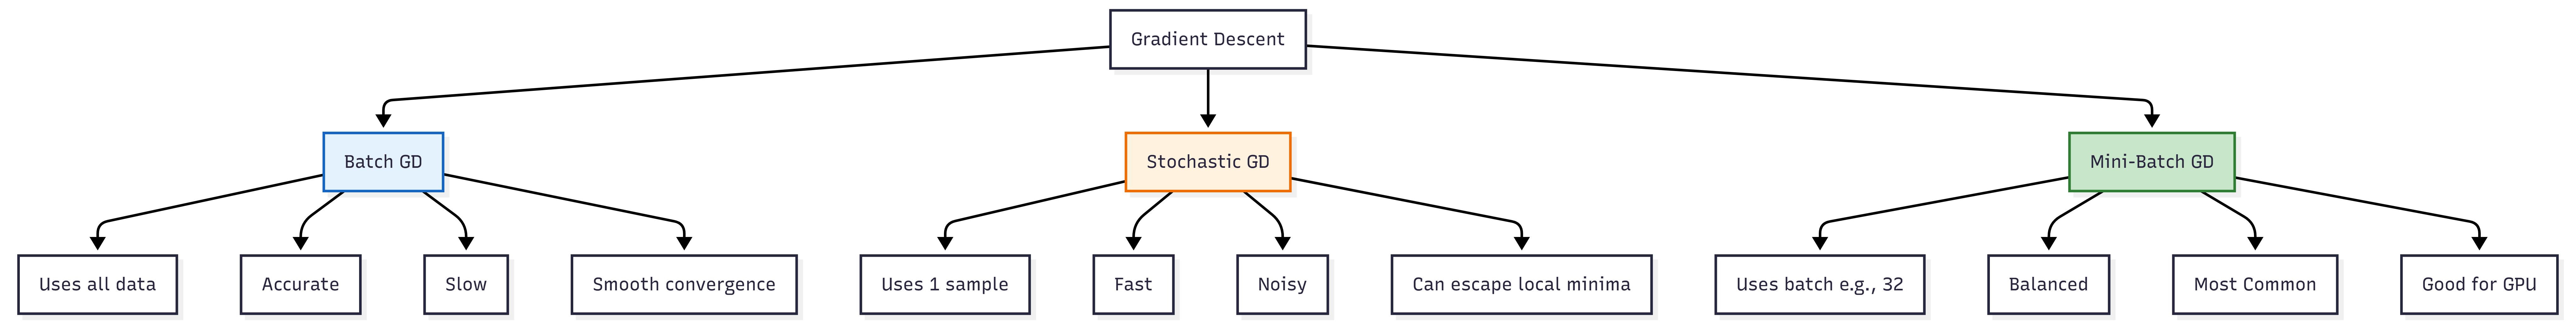